<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_3_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

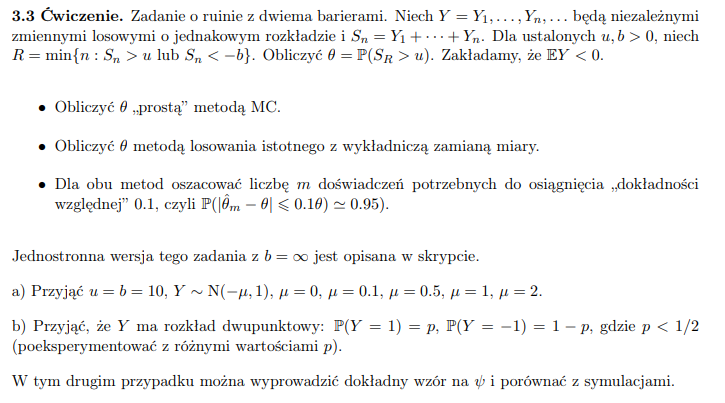

## Simulations
---

### Crude Monte Carlo
---

In [19]:
import numpy as np
import pandas as pd
from IPython.display import display, HTML

In [12]:
# setup for experiments
N = 100_000
u = 10
b = 10

mus = [0.0, 0.1, 0.5, 1.0, 2.0]
ps = [0.45, 0.4, 0.3, 0.2, 0.1, 0.05]

results_cmc_norm = {}
results_cmc_binom = {}

In [13]:
# simulation for normal distribution
for mu in mus:
    # preparing for N independent samples
    active = np.ones(N, dtype=bool)
    S = np.zeros(N)                 # start at 0
    hits = np.zeros(N, dtype=bool)  # tracks cases when upper bound was hit

    # repeat while there are active games
    while np.any(active):
        # updating active players
        S[active] += np.random.normal(-mu, 1, size=active.sum())

        # checking which players hit the bounds
        crossed_u = S[active] > u
        crossed_b = S[active] < -b
        stopped = crossed_u | crossed_b

        # updatinf upper hits tracker
        hits[active] = crossed_u

        # making players who hit the bound inactive
        active[active] = ~stopped

    # calculating metrics
    theta_cmc = np.mean(hits)
    var_cmc = np.var(hits, ddof=1)
    results_cmc_norm[mu] = (theta_cmc, var_cmc)
    print(f"  mu={mu:<3}: θ = {theta_cmc:.6e}")

  mu=0.0: θ = 5.026800e-01
  mu=0.1: θ = 1.076900e-01
  mu=0.5: θ = 2.000000e-05
  mu=1.0: θ = 0.000000e+00
  mu=2.0: θ = 0.000000e+00


In [14]:
# simulation for Two-Point distribution
for p in ps:
    active = np.ones(N, dtype=bool)
    S = np.zeros(N)
    hits = np.zeros(N, dtype=bool)

    while np.any(active):
        steps = np.where(np.random.rand(active.sum()) < p, 1, -1)
        S[active] += steps
        crossed_u = S[active] >= u
        crossed_b = S[active] <= -b
        stopped = crossed_u | crossed_b
        hits[active] = crossed_u
        active[active] = ~stopped

    theta_cmc = np.mean(hits)
    var_cmc = np.var(hits, ddof=1)
    results_cmc_binom[p] = (theta_cmc, var_cmc)
    print(f"  p={p:<4}: θ = {theta_cmc:.6e}")

  p=0.45: θ = 1.186500e-01
  p=0.4 : θ = 1.694000e-02
  p=0.3 : θ = 2.000000e-04
  p=0.2 : θ = 0.000000e+00
  p=0.1 : θ = 0.000000e+00
  p=0.05: θ = 0.000000e+00


### Importance sampling
---

Since the expected value of the steps is negative ($\mathbb{E}[Y] < 0$), reaching the upper barrier $u$ is an extremely rare event, making crude simulations highly inefficient. To solve this, we apply an exponential change of measure by introducing a parameter $\gamma$.

Changing the distribution alters the probability of each step, requiring us to multiply the final outcome by the cumulative likelihood ratio over $R$ steps, which equals $(M(\gamma))^R e^{-\gamma S_R}$. By specifically choosing $\gamma$ such that the moment-generating function $M(\gamma) = \mathbb{E}[e^{\gamma Y}] = 1$, the time-dependent term $1^R$ completely vanishes. This elegantly simplifies the correction weight, making it completely independent of the random stopping time while reversing the drift to positive. To correct for this altered probability, we multiply the outcome of each successful trajectory by this simplified likelihood ratio weight:

$$\theta = \mathbb{E}_{\gamma}\left[ \mathbb{1}_{\{S_R > u\}} e^{-\gamma S_R} \right]$$

In [15]:
results_is_norm = {}
results_is_binom = {}

For steps following a normal distribution $Y \sim \mathcal{N}(-\mu, 1)$, the theoretical moment-generating function is given by $M(\gamma) = \exp(-\mu\gamma + \frac{\gamma^2}{2})$. To apply our importance sampling strategy, we set $M(\gamma) = 1$, which requires the exponent to be exactly zero. Solving the equation $-\mu\gamma + \frac{\gamma^2}{2} = 0$ yields the optimal non-zero parameter $\gamma = 2\mu$. Consequently, the shifted distribution for our simulation naturally becomes $\mathcal{N}(\mu, 1)$, perfectly reversing the negative drift into a positive one.

In [16]:
# simulation for normal distribution
for mu in mus:
    gamma = 2 * mu
    sim_mu = mu if mu > 0 else -mu

    active = np.ones(N, dtype=bool)
    S = np.zeros(N)
    hits = np.zeros(N, dtype=bool)

    while np.any(active):
        S[active] += np.random.normal(sim_mu, 1, size=active.sum())
        crossed_u = S[active] > u
        crossed_b = S[active] < -b
        stopped = crossed_u | crossed_b
        hits[active] = crossed_u
        active[active] = ~stopped

    # obtaning weights and applying them
    weights = np.exp(-gamma * S)
    Y_is = hits * weights

    # calculating metrics
    theta_is = np.mean(Y_is)
    var_is = np.var(Y_is, ddof=1)
    results_is_norm[mu] = (theta_is, var_is)
    print(f"  mu={mu:<3}: θ = {theta_is:.6e}")

  mu=0.0: θ = 4.994800e-01
  mu=0.1: θ = 1.072069e-01
  mu=0.5: θ = 2.537164e-05
  mu=1.0: θ = 6.584567e-10
  mu=2.0: θ = 5.033876e-19


For the simple random walk where $Y \in \{1, -1\}$ with probabilities $p$ and $q = 1-p$ respectively, the moment-generating function takes the form $M(\gamma) = p e^\gamma + q e^{-\gamma}$. Setting this expected value to $1$ and multiplying by $e^\gamma$ leads to the quadratic equation $p e^{2\gamma} - e^\gamma + q = 0$. The non-trivial root of this equation is $e^\gamma = q/p$, which provides our optimal parameter $\gamma = \ln(q/p)$. In practice, this mathematical change of measure has a beautifully simple physical interpretation: it simply swaps the probabilities, causing the process to step upwards with the higher probability $q$.

In [17]:
# simulation for Two-Point distribution
for p in ps:
    q = 1 - p
    gamma = np.log(q/p)

    active = np.ones(N, dtype=bool)
    S = np.zeros(N)
    hits = np.zeros(N, dtype=bool)

    while np.any(active):
        steps = np.where(np.random.rand(active.sum()) < q, 1, -1)
        S[active] += steps
        crossed_u = S[active] >= u
        crossed_b = S[active] <= -b
        stopped = crossed_u | crossed_b
        hits[active] = crossed_u
        active[active] = ~stopped

    weights = np.exp(-gamma * S)
    Y_is = hits * weights

    theta_is = np.mean(Y_is)
    var_is = np.var(Y_is, ddof=1)
    results_is_binom[p] = (theta_is, var_is)
    print(f"  p={p:<4}: θ = {theta_is:.6e}")

  p=0.45: θ = 1.184683e-01
  p=0.4 : θ = 1.704638e-02
  p=0.3 : θ = 2.089974e-04
  p=0.2 : θ = 9.536743e-07
  p=0.1 : θ = 2.867972e-10
  p=0.05: θ = 1.631038e-13


### Estimating the required sample size
----

To determine the required sample size $m$ for achieving a relative precision of $0.1$ with $95\%$ confidence, we utilize the Central Limit Theorem where the error bound is defined as: $$1.96 \cdot \sigma/\sqrt{m} \le 0.1 \cdot \theta.$$.
Let us square both sides of this inequality: $$m \ge (1.96^2 / 0.1^2) \cdot (\sigma^2 / \theta^2),$$
which simplifies to:
$$m \ge 384.16 \cdot (\sigma^2 / \theta^2).$$



 *   **Deriving formula for $\theta$ for the Two-Point distribution**


Now, we will derive the formula for $\theta$ for the Two-Point distribution. Let $\phi(x)$ represent the probability of success starting from position $x$. This leads to the equation:
$$\phi(x) = p\phi(x+1) + q\phi(x-1)$$
with boundary conditions $\phi(u) = 1$ and $\phi(-b) = 0$.

Next, this equation can be solved by assuming a solution of the form $\phi(x) = r^x$, by which we obtain the characteristic equation:
$$p r^2 - r + q = 0$$
This equation has two solutions $r_1 = 1$ and $r_2 = q/p$.

Therefore, the general solution for $\phi(x)$ can be written as:
$$\phi(x) = A \cdot (1)^x + B \cdot (q/p)^x = A + B \left(\frac{q}{p}\right)^x$$

Boundary conditions allow us to compute the constants $A$ and $B$, and we finally obtain the formula for $\theta$:
$$\theta = \frac{1 - (q/p)^b}{1 - (q/p)^{u+b}}$$

In [23]:
def compute_m(theta, var):
    """Computes how big m must be to achieve accuracy of 0.1 with 95% confidence"""
    if theta == 0 or np.isnan(theta):
        return np.inf
    return 384.16 * (var / (theta**2))


# table for normal distribution
data_norm = []
for mu in mus:
    t_cmc, v_cmc = results_cmc_norm[mu]
    t_is, v_is = results_is_norm[mu]

    m_cmc = compute_m(t_cmc, v_cmc)
    m_is = compute_m(t_is, v_is)

    data_norm.append((mu, t_cmc, m_cmc, t_is, m_is))

df_norm = pd.DataFrame(data_norm, columns=["mu", "θ (CMC)", "Required m (CMC)", "θ (IS)", "Required m (IS)"])

# table for Two-Point distribution
data_binom = []
for p in ps:
    q = 1 - p
    # theoretical formula for player's ruin
    theta_exact = (1 - (q/p)**b) / (1 - (q/p)**(u+b))

    t_cmc, v_cmc = results_cmc_binom[p]
    t_is, v_is = results_is_binom[p]

    m_cmc = compute_m(t_cmc, v_cmc)
    m_is = compute_m(t_is, v_is)

    data_binom.append((p, theta_exact, t_cmc, m_cmc, t_is, m_is))

df_binom = pd.DataFrame(data_binom, columns=["p", "θ (Theory)", "θ (CMC)", "m (CMC)", "θ (IS)", "m (IS)"])



# displaying tables
display(HTML("<h3>A) Normal Distribution Y ~ N(-mu, 1)</h3>"))
display(df_norm.style.format({
    "θ (CMC)": "{:.3e}", "Required m (CMC)": "{:.2e}",
    "θ (IS)": "{:.3e}", "Required m (IS)": "{:.2e}"
}).set_properties(**{'text-align': 'center'}))

display(HTML("<br><h3>B) Two-Point Distrubtion</h3>"))
display(df_binom.style.format({
    "θ Dokładne": "{:.3e}", "θ (CMC)": "{:.3e}", "m (CMC)": "{:.2e}",
    "θ (IS)": "{:.3e}", "m (IS)": "{:.2e}"
}).set_properties(**{'text-align': 'center'}))

,mu,θ (CMC),Required m (CMC),θ (IS),Required m (IS)
0,0.000000,5.027e-01,3.80e+02,4.995e-01,3.85e+02
1,0.100000,1.077e-01,3.18e+03,1.072e-01,5.14e+01
2,0.500000,2.000e-05,1.92e+07,2.537e-05,7.83e+01
3,1.000000,0.000e+00,inf,6.585e-10,2.94e+02
4,2.000000,0.000e+00,inf,5.034e-19,1.26e+03


,p,θ (Theory),θ (CMC),m (CMC),θ (IS),m (IS)
0,0.450000,0.118501,1.187e-01,2.85e+03,1.185e-01,5.18e+01
1,0.400000,0.017046,1.694e-02,2.23e+04,1.705e-02,6.65e+00
2,0.300000,0.000209,2.000e-04,1.92e+06,2.090e-04,8.07e-02
3,0.200000,0.000001,0.000e+00,inf,9.537e-07,0.00e+00
4,0.100000,0.000000,0.000e+00,inf,2.868e-10,2.00e-28
5,0.050000,0.000000,0.000e+00,inf,1.631e-13,9.20e-30
